<a href="https://colab.research.google.com/github/ViktorMyronenko/PythonAI-ITStep/blob/Class_work/26_02_2025%20%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Імпорт модулів

In [1]:
import torch


# Завдання 1

Перегляньте інформацію про доступні процесори, та виведіть про них інформацію

In [2]:
if torch.cuda.is_available():
  device = 'cuda'
else:
  device = 'cpu'
device

'cuda'

# Завдання 2
Підключіть colab до процесора GPU, та знову виведіть інформацію про доступні процесори

In [3]:
device

'cuda'

# Завдання 3
Створіть випадковий тензор розміру (2, 3). Виведіть інформацію про його:

* розмір
* тип даних
* процесор
* наявність градієнта

In [7]:
tensor = torch.randn(3, 4)
tensor.shape
tensor.dtype
tensor.device
tensor.requires_grad

False

# Завдання 4

Створіть 2 тензора розміру 100. Використовуючи лише модуль `torch` обрахуйте середьню абсолютну похибку(mae) між ними. Виведіть результат як число

In [13]:
tensor1 = torch.randn(100, requires_grad=True)
tensor2 = torch.randn(100)

res1 = abs(tensor2 - tensor1)

res1

mae = res1.mean()

mae

tensor(1.3087, grad_fn=<MeanBackward0>)

# Завдання 5

Створіть 3 випадкових тензора з розмірами:
* 32х28х28
* 16х28х28
* 64х28х28

Об'єднайте їх по першій розмірності. Результат має мати розмір 112х28х28

In [16]:
tensor1 = torch.randn(32, 28, 28)
tensor2 = torch.randn(16, 28, 28)
tensor3 = torch.randn(64, 28, 28)

res1 = torch.cat([tensor1, tensor2, tensor3], axis=0)
res1.shape

torch.Size([112, 28, 28])

# Завдання 6
Застосуйте метод градієнтного спуску для функції

In [17]:
def f(x):
  return x**2/3 + torch.sin(torch.pi*x)

In [41]:
from torch.optim import Adam

tensor1 = torch.tensor(2.5, requires_grad=True, device=device)

tensor1

optimazer = Adam([tensor1], lr=1e-1)

for i in range(500):
  loss = f(tensor1)
  loss.backward()

  optimazer.step()
  optimazer.zero_grad()

  if i % 100 == 0:
    print(loss.item())

tensor1


3.0833334922790527
-0.29769694805145264
-0.2977929711341858
-0.2977929711341858
-0.2977929711341858


tensor(1.4037, device='cuda:0', requires_grad=True)

In [64]:
from torch.optim import Adam # Знайти такий х щоб f(x)=0

x = torch.tensor(2.5, requires_grad=True, device=device)
zero_tensor = torch.tensor(1.0, device=device)

optimazer = Adam([x], lr=1e-1)

for i in range(500):
  res = f(x)
  loss = (res - zero_tensor)**2  # mse
  loss.backward()

  optimazer.step()
  optimazer.zero_grad()

  if i % 100 == 0:
    print(loss.item())

f(x)

4.340278625488281
0.00010740376455942169
5.46265255252365e-11
3.197442310920451e-14
3.197442310920451e-14


tensor(1.0000, device='cuda:0', grad_fn=<AddBackward0>)

In [65]:
print(zero_tensor)

tensor(1., device='cuda:0')


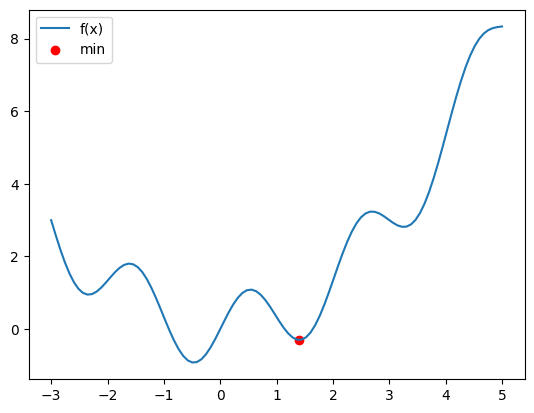

In [42]:
import matplotlib.pyplot as plt

xs = torch.linspace(-3, 5, 100)
plt.plot(xs.cpu(), f(xs).cpu(), label='f(x)')
plt.scatter(tensor1.item(), f(tensor1).item(), c='red', label='min')
plt.legend()

# Завдання 7
Застосуйте метод градієнтного спуску для функції. Мінімум функції рівний 0

In [44]:
def f1(x, y):
  # функція Швефеля
  return  418.9829*2 - x*torch.sin(x.abs().sqrt()) - y*torch.sin(y.abs().sqrt())

def f2(x, y):
  # трьохгорбна функція
  return 2*x**2  - 1.05*x**4 + 1/6*x**6 + x*y  + y**2

def f3(x, y):
  # функція птах
  return 106.7645 + torch.sin(x)*torch.exp((1-torch.cos(y))**2) + \
  torch.cos(y)*torch.exp((1-torch.sin(x))**2) + \
  (x-y)**2

In [51]:
from torch.optim import Adam

x = torch.tensor(2.5, requires_grad=True, device=device)

y = torch.tensor(5.0, requires_grad=True, device=device)

optimazer = Adam([x, y], lr=1e-1)

for i in range(1000):
  loss = f1(x, y)
  loss.backward()

  optimazer.step()
  optimazer.zero_grad()

  if i % 100 == 0:
    print(loss.item(), x.item(), y.item(), sep='\t')


831.5322265625	2.5999999046325684	5.099999904632568
830.0751953125	5.2352986335754395	5.238444805145264
830.0751953125	5.2391180992126465	5.239201068878174
830.0751953125	5.239199161529541	5.239199638366699
830.0751953125	5.239199161529541	5.239199161529541
830.0751953125	5.239199161529541	5.239199638366699
830.0751953125	5.239199161529541	5.239199638366699
830.0751953125	5.239199161529541	5.239199638366699
830.0751953125	5.239199161529541	5.239199638366699
830.0751953125	5.239199161529541	5.239199638366699
